# Smoke-Screen 💨
### Earnings the cash doesn't back — and the firms that disappoint

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Accrual anomaly replicates?: Confirmed](https://img.shields.io/badge/Accrual_anomaly_replicates%3F-Confirmed-8b949e?style=flat-square)

Profit on the income statement and cash in the bank aren't the same thing. The gap — *accruals* — is the smoke: accounting estimates that can reverse. Sloan showed firms with high accruals subsequently underperform, and on real SEC filings the effect replicates cleanly: cash-backed earners beat accrual-heavy ones by ~6%/year.

> 📓 **Plain-language layer.** The t-stat and the caveats are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (smoke_screen/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from smoke_screen import data, strategy as st
sig, fwd = data.fetch_panel()                  # cache-first (shared EDGAR pull)
h = st.quantile_hedge(sig, fwd, q=0.2, long_high=False)   # long low accruals


## The answer first 🎯

| The claim | The data (~2007–2025) |
|---|---|
| "High-accruals firms underperform" | True: hedge **+5.9%/yr**, hit **72%**. |
| "Cash-backed earners win" | Long leg **+25.0%** vs market +19.6%. |
| "Significant?" | Yes — Sharpe **0.64 (t ≈ 2.7)**. |

## 1 · The claim

Sloan (1996): split earnings into a cash part and an accrual part. The accrual part (receivables, inventory, deferrals) is less persistent and the market over-trusts it — so high-accruals firms disappoint. Long low-accruals, short high-accruals.

## 2 · So what?

It's a clean, economically sensible signal you can read straight off the cash-flow statement: does the reported profit show up as cash? If 'quality of earnings' predicts returns, that's a real, fundamental edge — and a rare one that isn't priced away.

## 3 · How would we even know?

Compute accruals = (net income − operating cash flow) / assets from SEC filings, sort firms, go long the cash-backed (low-accruals) and short the accrual-heavy, and measure the annual hedge and its significance.

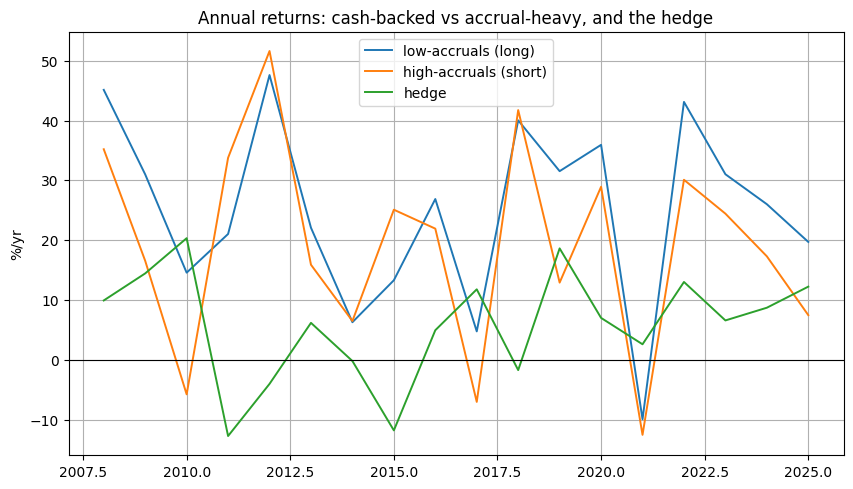

hedge mean +5.89%/yr, Sharpe 0.64, t≈2.7, hit 72%


In [2]:
disp=h[['low','high','hedge']].rename(columns={'low':'low-accruals (long)','high':'high-accruals (short)'})
ax=(disp*100).plot(title='Annual returns: cash-backed vs accrual-heavy, and the hedge',lw=1.4)
ax.axhline(0,color='k',lw=.8); ax.set_ylabel('%/yr'); plt.show()
s=st.summary(h['hedge']); print(f"hedge mean {s['mean']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, t≈{s['tstat']:.1f}, hit {s['hit_rate']:.0%}")

## 4 · The teardown

The low-accruals (cash-backed) leg wins most years — and beats the market, not just the short leg. A genuine, significant edge.

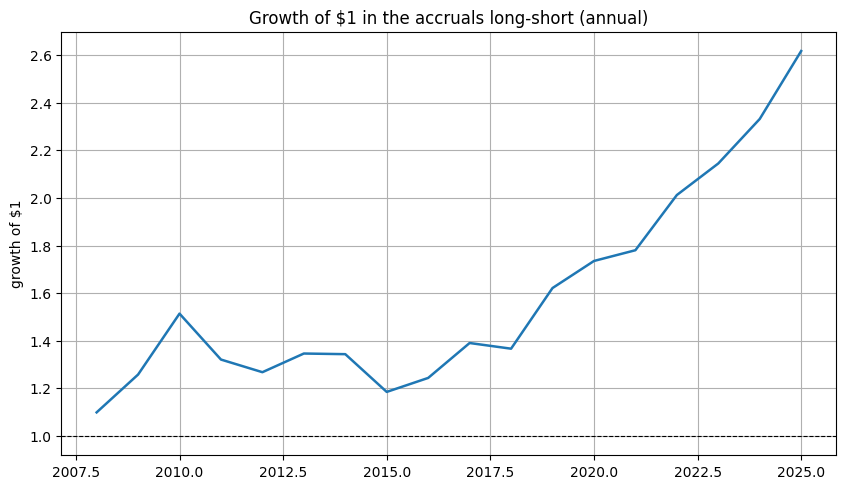

In [3]:
eq=(1+h['hedge']).cumprod()
ax=eq.plot(title='Growth of $1 in the accruals long-short (annual)',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

**Read it plainly.** A steady climb — quality of earnings really does predict returns. The rare bench result that's *real* and points the right way, not a mirage.

## 5 · The verdict

**Signal: Real** — +5.9%/yr, t ≈ 2.7, 72% hit. **Tradability: Fragile** — short-side frictions, documented post-2000 fade. **Accrual anomaly replicates?: Confirmed.**

## 6 · Could you actually trade it?

The long leg (own cash-backed earners) is easy and even beats the market. The full hedge needs shorting accrual-heavy names — costlier — and the edge is known to have faded since ~2003 as quants piled in. Real, but handle with care.

## 7 · Going further 🚪

The companion fundamental study is [Study 51 Blue-Chip](../../51-blue-chip/) (quality / gross profitability). Together they show real fundamental signals do survive on large caps — unlike the inverted [53 Jackpot](../../53-jackpot/) / [54 Static](../../54-static/).